# 03 — Learner Segmentation Experiments

**Phase 3A.** Controlled experiments to identify a defensible learner segmentation
representation and clustering configuration.

This notebook is an **explorable view** of the experiments, not their implementation.
Everything shown is produced by `scripts/run_segmentation_experiments.py` and the
`edupro.segmentation` package (CLAUDE.md §19).

**Leakage discipline.** All experiments run on the **fit window** — every interaction
before the pre-registered test cut of 2025-10-18 — so the segment assignments can
feed the Phase 3B recommendation evaluation without leaking (control L4).

In [1]:
import json

import pandas as pd
from IPython.display import Image, display

from edupro import config

SEG = config.ARTIFACTS_DIR / "segmentation"
results = json.loads((SEG / "segmentation_results.json").read_text(encoding="utf-8"))
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)

p = results["provenance"]
print(f"window          : {p['window']}")
print(f"test cut        : {p['test_cut']}")
print(f"learners (fit)  : {p['n_learners_fit_window']:,}")
print(f"interactions    : {p['n_interactions_fit_window']:,}")
print(f"seed            : {p['seed']}")

window          : fit (all interactions before the pre-registered test cut)
test cut        : 2025-10-18
learners (fit)  : 2,650
interactions    : 7,992
seed            : 42


## Experiment 1 — Feature representations

Ten arms, each a complete recipe: which feature blocks, how the 12-level category
preference is encoded, block weighting, and scaling. Every arm is swept over the
full k range, so the comparison does not depend on a k chosen for one of them.

In [2]:
summary = pd.DataFrame(results["EXP-011a_representations"])
display(summary[[
    "name", "variant", "n_features", "category_encoding", "scaler",
    "best_k", "best_silhouette", "min_cluster_share_at_best_k",
    "intra_cluster_similarity", "demographic_share", "top_feature_eta_squared",
]].sort_values("best_silhouette", ascending=False).reset_index(drop=True))

print("\ndescriptions:")
for _, row in summary.iterrows():
    print(f"  {row['name']:<24} {row['description']}")

,name,variant,n_features,category_encoding,scaler,best_k,best_silhouette,min_cluster_share_at_best_k,intra_cluster_similarity,demographic_share,top_feature_eta_squared
0,B_robust_scaled,B,25,proportion,robust,2,0.715913,0.1706,0.239114,0.0000,total_courses
1,B_no_category,B,13,none,standard,10,0.434895,0.0596,0.710908,0.0000,preflevel_Beginner
2,B_facets,B,15,facets,standard,2,0.393321,0.2045,0.287137,0.0000,diversity_ratio
3,B_no_level,B,22,proportion,standard,9,0.302748,0.0558,0.357611,0.0000,total_courses
4,B_proportion_weighted,B,25,proportion,standard,4,0.292188,0.1962,0.420262,0.0000,preflevel_Intermediate
5,B_decorrelated,B,23,proportion,standard,10,0.266550,0.0502,0.385877,0.0000,total_courses
6,B_teacher,B,28,proportion,standard,2,0.221247,0.2008,0.287873,0.0000,teacher_loyalty
7,A_proportion,A,27,proportion,standard,9,0.218849,0.0509,0.397772,0.0008,total_courses
8,B_one_hot,B,25,one_hot,standard,2,0.211516,0.2004,0.285303,0.0000,diversity_ratio
9,B_proportion,B,25,proportion,standard,6,0.208907,0.0619,0.496995,0.0000,cat_share_programming



descriptions:
  B_proportion             Variant B (behaviour only), category as a 12-dim share vector (E-B)
  B_one_hot                Variant B, category one-hot on the modal category (E-A, the control arm)
  B_facets                 Variant B, category as breadth/concentration facets only (E-C)
  B_no_category            Variant B with no category representation at all (lower bound)
  A_proportion             Variant A (behaviour + demographics), category share vector
  B_proportion_weighted    Variant B, share vector, blocks weighted by 1/sqrt(columns) (EXP-011b)
  B_decorrelated           Variant B, share vector, volume-redundant features dropped (EXP-011e)
  B_robust_scaled          Variant B, share vector, RobustScaler instead of StandardScaler
  B_teacher                Variant B + teacher-derived block (EXP-014 arm)
  B_no_level               Variant B, share vector, preferred_level one-hot removed. Added after the first run showed the k=4 partition was almost purely a level 

### `B_robust_scaled` is a scaling artefact, not a better representation

It posts by far the highest silhouette (0.716). That is a pathology, not a result:
two mandated features have an **interquartile range of exactly zero**, because 54%
of learners have a single course, so their 25th, 50th and 75th percentiles
coincide. RobustScaler leaves those columns unscaled while compressing the others,
manufacturing an artificially separable axis.

This settles the scaler decision deferred in Phase 1 (D5): **StandardScaler**.

In [3]:
diag = results["scaler_diagnostic"]
print("features with IQR == 0:", diag["features_with_zero_iqr"])
display(pd.DataFrame(diag["per_feature"]).T)

features with IQR == 0: ['avg_courses_per_category', 'diversity_ratio']


,q25,q75,iqr,degenerate
total_courses,1.0,2.0,1.0,False
avg_courses_per_category,1.0,1.0,0.0,True
enrollment_frequency,0.0417,1.0,0.958333,False
avg_course_rating,2.5367,3.85,1.313333,False
avg_spend,0.0,130.5845,130.584545,False
diversity_score,1.0,2.0,1.0,False
learning_depth_index,0.5,1.5,1.0,False
free_ratio,0.4444,1.0,0.555556,False
diversity_ratio,1.0,1.0,0.0,True
activity_span_days,0.0,147.75,147.75,False


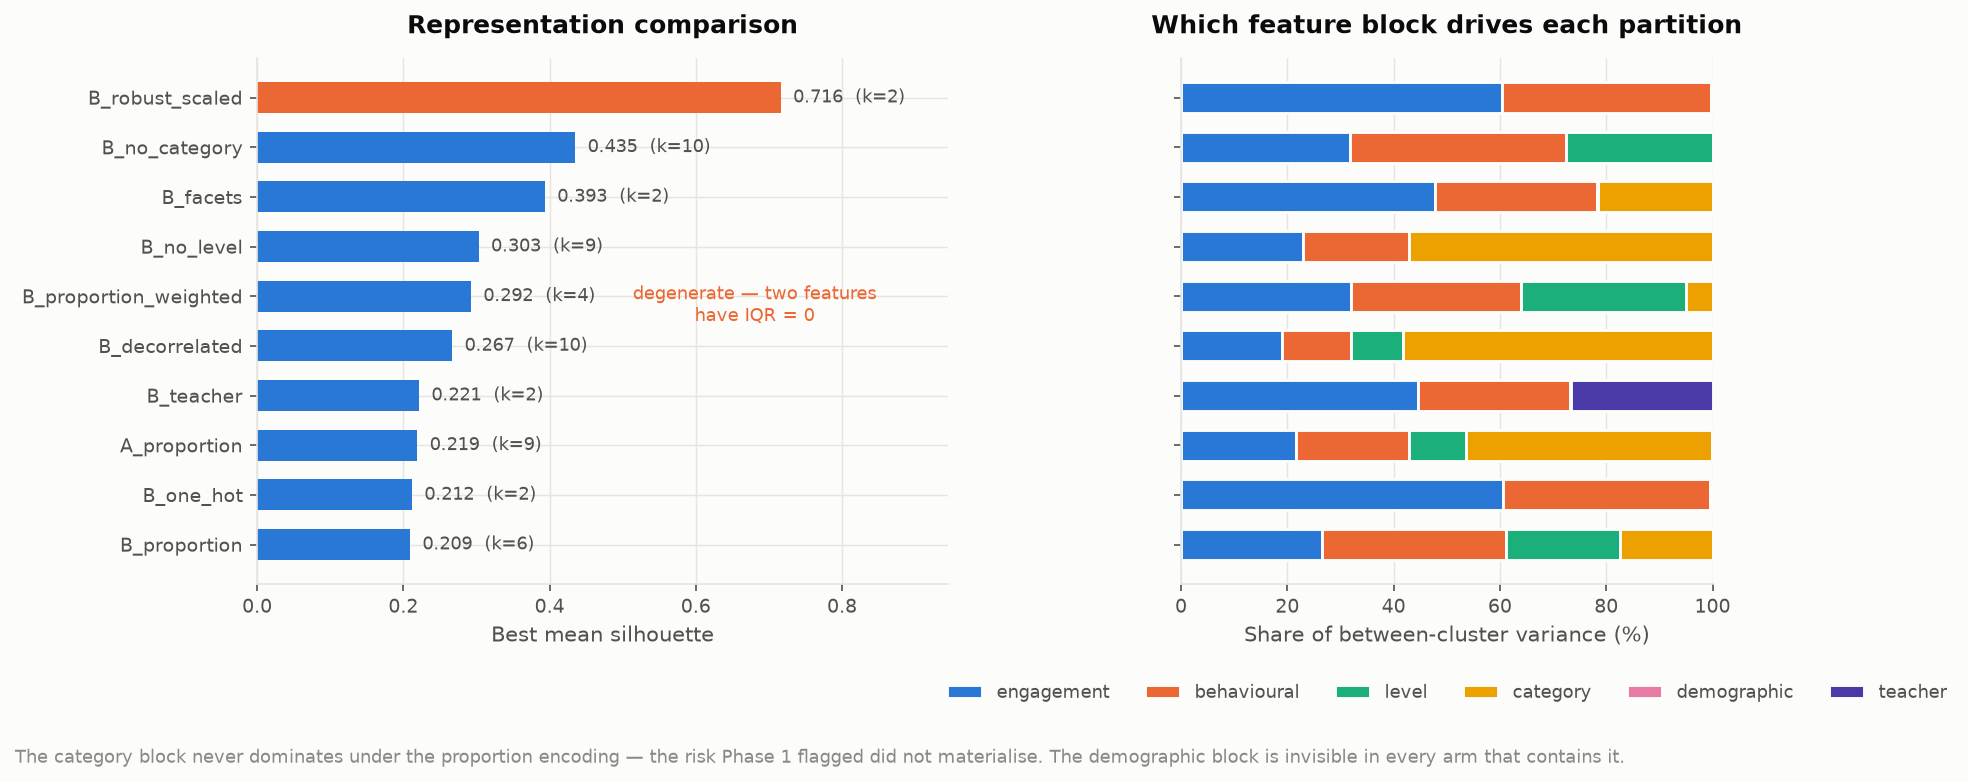

In [4]:
display(Image(filename=str(SEG / "06_representation_comparison.png")))

## Experiment 2 — K-Means and the choice of k

The brief mandates elbow and silhouette. Neither is allowed to decide alone: the
pre-registered rule also requires every cluster to hold ≥5% of learners **and** to
reach a bootstrap Jaccard of ≥0.60.

,k,inertia,silhouette,calinski_harabasz,davies_bouldin,min_cluster_share,intra_cluster_similarity,seed_stability_ari
0,2,55391.3970,0.177130,519.0983,1.554280,0.200377,0.271630,1.000000
1,3,49369.2770,0.173304,452.5413,2.213792,0.198868,0.374297,1.000000
2,4,45448.3265,0.194600,403.6909,2.145305,0.196981,0.416343,0.999587
3,5,43230.9267,0.201856,352.0943,1.997502,0.053962,0.422638,0.863458
4,6,40925.0848,0.208907,327.2275,1.947381,0.061887,0.496995,0.798106
5,7,39662.4832,0.230524,295.2866,1.868971,0.046415,0.403851,0.676684
6,8,37076.8700,0.234872,296.9715,1.716846,0.048679,0.499859,0.639270
7,9,35415.6263,0.261333,287.4211,1.786341,0.046792,0.434954,0.617007
8,10,33312.3673,0.268467,290.0336,1.636364,0.043774,0.463030,0.557135


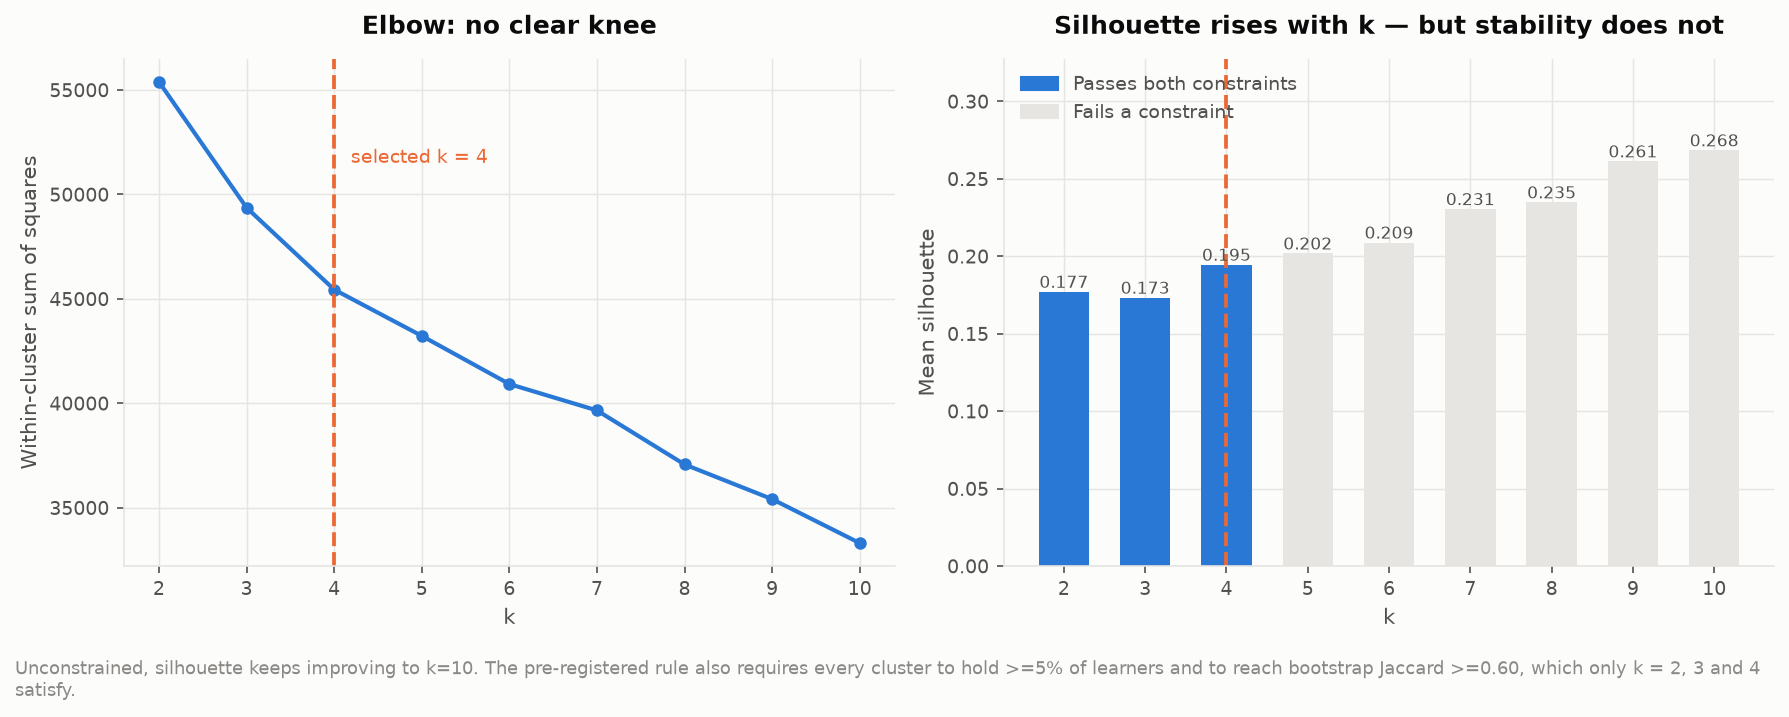

In [5]:
sweep = pd.DataFrame(results["EXP-010_k_sweep"])
display(sweep[[
    "k", "inertia", "silhouette", "calinski_harabasz", "davies_bouldin",
    "min_cluster_share", "intra_cluster_similarity", "seed_stability_ari",
]])
display(Image(filename=str(SEG / "01_elbow_and_silhouette.png")))

,k,silhouette,min_cluster_share,mean_bootstrap_jaccard,n_unstable_clusters,passes_constraints,failure_reasons
0,2,0.177130,0.2004,0.9825,0,True,[]
1,3,0.173304,0.1989,0.9898,0,True,[]
2,4,0.194600,0.1970,0.9985,0,True,[]
3,5,0.201856,0.0540,0.7477,1,False,[1 cluster(s) below Jaccard 0.60]
4,6,0.208907,0.0619,0.7028,2,False,[2 cluster(s) below Jaccard 0.60]
5,7,0.230524,0.0464,0.5116,5,False,"[smallest cluster 4.6% < 5%, 5 cluster(s) belo..."
6,8,0.234872,0.0487,0.5494,6,False,"[smallest cluster 4.9% < 5%, 6 cluster(s) belo..."
7,9,0.261333,0.0468,0.5339,6,False,"[smallest cluster 4.7% < 5%, 6 cluster(s) belo..."
8,10,0.268467,0.0438,0.6329,5,False,"[smallest cluster 4.4% < 5%, 5 cluster(s) belo..."


silhouette-optimal k, unconstrained : 10
k passing BOTH constraints          : [2, 3, 4]
chosen k                            : 4


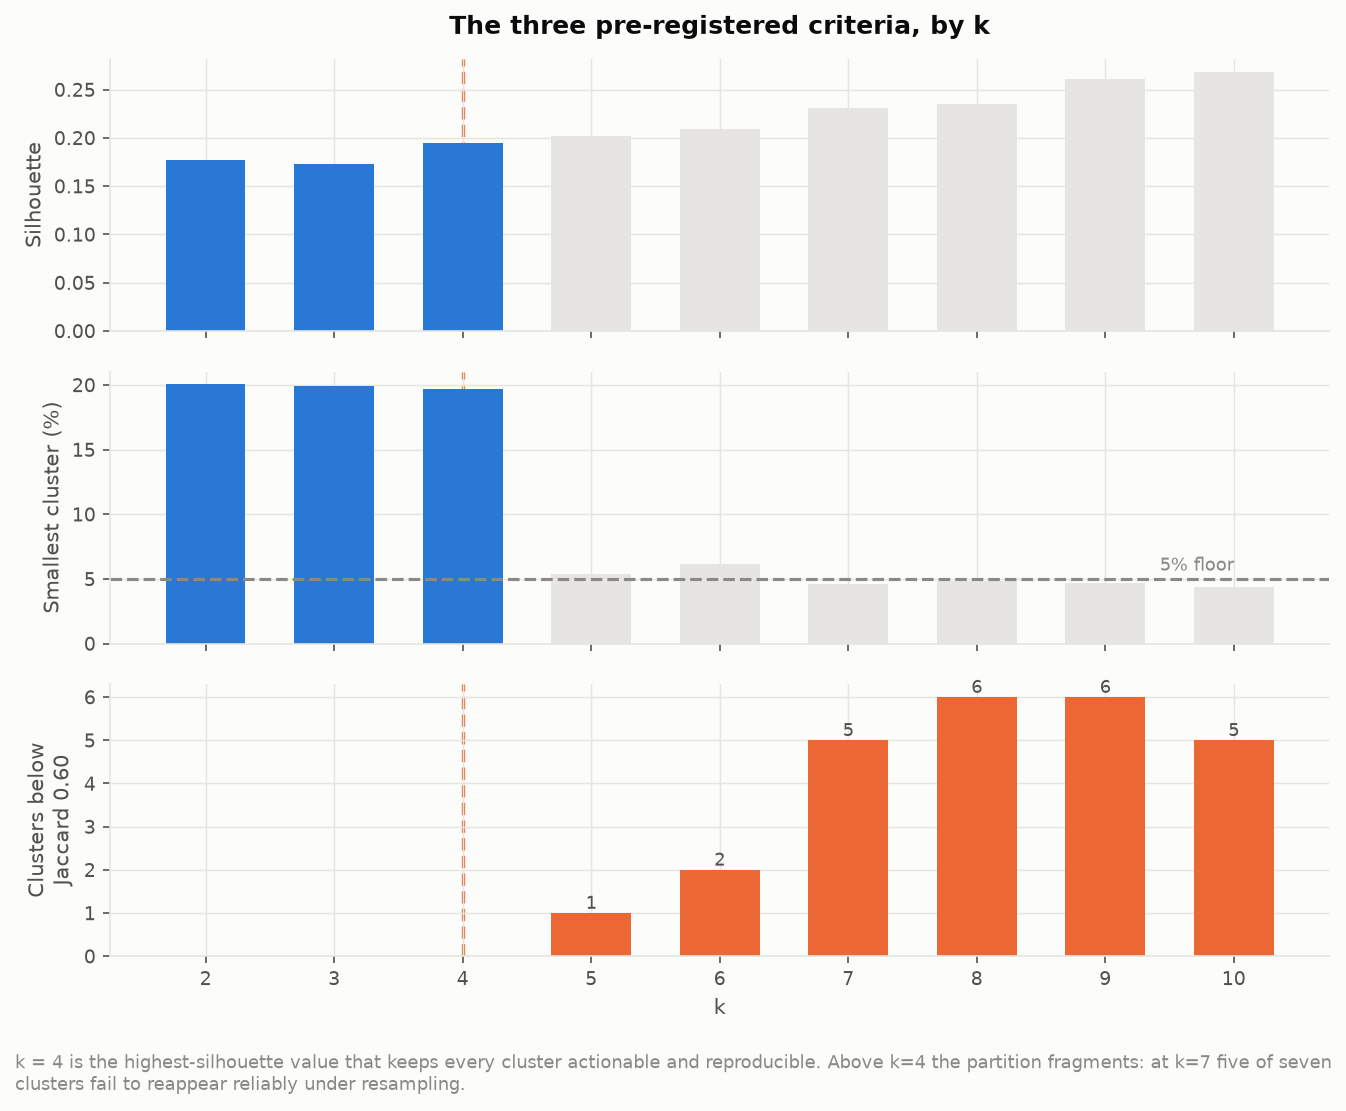

In [6]:
candidates = pd.DataFrame(results["k_selection"]["candidates"])
display(candidates)
sel = results["k_selection"]
print(f"silhouette-optimal k, unconstrained : {sel['silhouette_optimal_k_unconstrained']}")
print(f"k passing BOTH constraints          : {sel['eligible_k']}")
print(f"chosen k                            : {sel['chosen_k']}")
display(Image(filename=str(SEG / "02_k_selection_constraints.png")))

### The gap statistic — an instrument that failed

Added in Phase 1 because it is the only criterion that can report *no structure*.
On this data it rises monotonically to the range ceiling and never turns over, so
it yields no verdict. Reported as a failure rather than dropped, and **not** read
as endorsing the largest k.

monotonically increasing : True
informative              : False
BIC-optimal k (GMM)      : 10


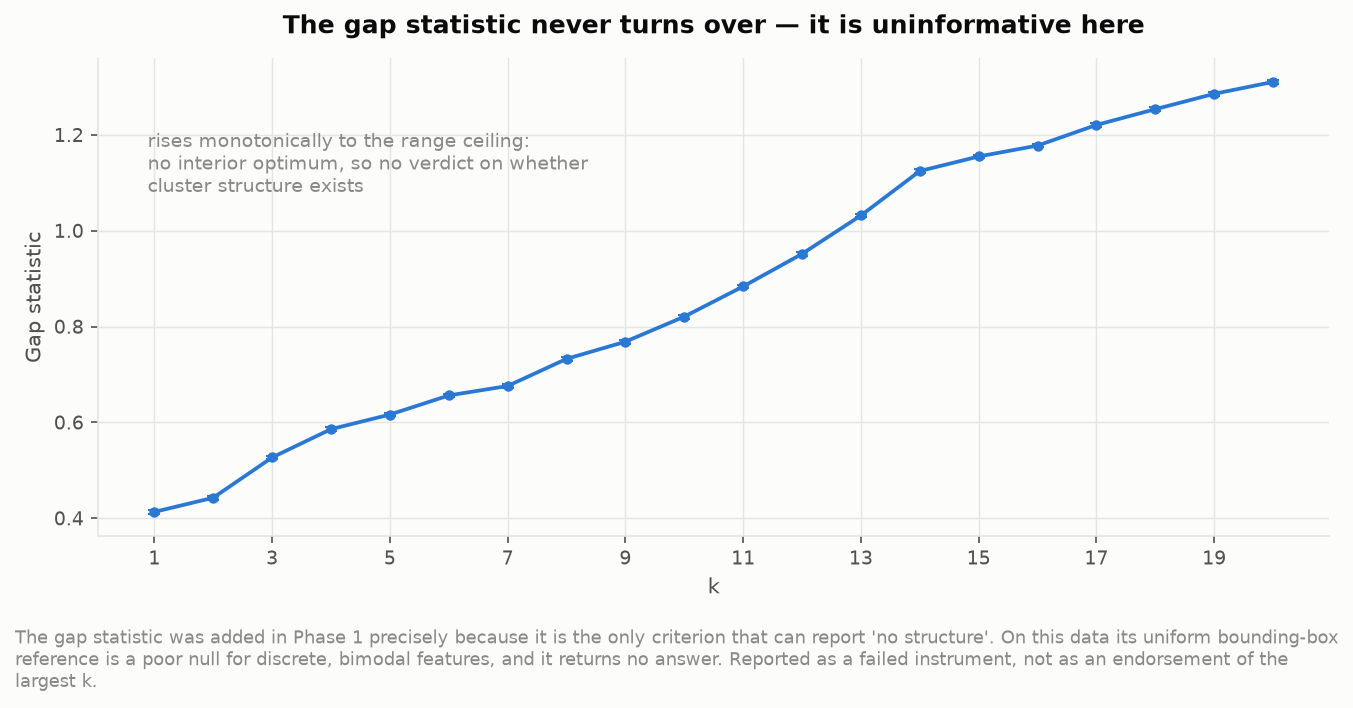

In [7]:
gap = results["EXP-010b_gap_statistic"]
print(f"monotonically increasing : {gap['monotonically_increasing']}")
print(f"informative              : {gap['informative']}")
print(f"BIC-optimal k (GMM)      : {results['EXP-010c_gmm']['bic_optimal_k']}")
display(Image(filename=str(SEG / "08_gap_statistic.png")))

## Experiment 3 — Hierarchical validation

Ward is the brief's validation method. It minimises within-cluster variance — the
same objective family K-Means optimises — so agreement between them is a weak form
of confirmation. Average linkage optimises something different and is the genuinely
independent test.

ARI K-Means vs Ward    : 0.3496
ARI K-Means vs Average : 0.0192
ARI Ward    vs Average : 0.0256

ward sizes    : [747, 374, 1005, 524]
average sizes : [21, 110, 113, 2406]


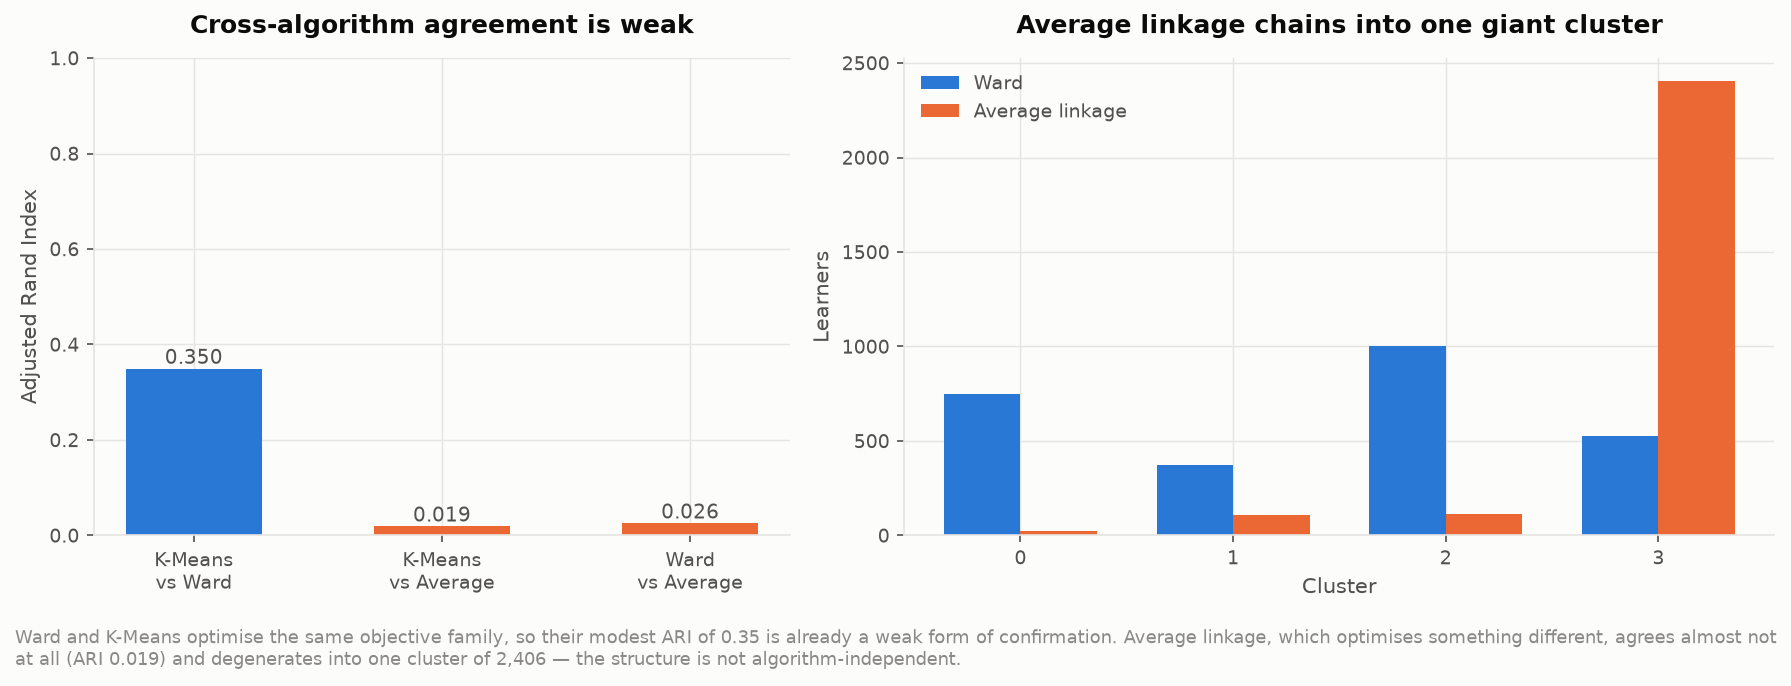

In [8]:
h = results["EXP-012_hierarchical"]
print(f"ARI K-Means vs Ward    : {h['ari_kmeans_vs_ward']:.4f}")
print(f"ARI K-Means vs Average : {h['ari_kmeans_vs_average']:.4f}")
print(f"ARI Ward    vs Average : {h['ari_ward_vs_average']:.4f}")
print(f"\nward sizes    : {list(h['ward_sizes'].values())}")
print(f"average sizes : {list(h['average_sizes'].values())}")
display(Image(filename=str(SEG / "09_hierarchical_validation.png")))

## Experiment 4 — Stability

Three checks: restarts across seeds, per-cluster bootstrap Jaccard, and subsample
consensus. The per-cluster values matter most — one loose segment among four tight
ones is a finding an average would conceal.

stability at the chosen k:
  k: 4
  n_bootstrap: 100
  per_cluster_jaccard: {'0': 0.9833, '1': 0.9962, '2': 0.9961, '3': 0.9813}
  mean_jaccard: 0.9892
  n_unstable_below_0.60: 0
  n_reliable_above_0.75: 4
  subsample_ari_mean: 0.9874
  subsample_ari_std: 0.0608
  all_clusters_reliable: True

stability across the whole k range:


,mean_jaccard,unstable,reliable,subsample_ari
k,,,,
2,0.9825,0,2,1.0000
3,0.9898,0,3,0.9991
4,0.9985,0,4,0.9761
5,0.7477,1,4,0.8443
6,0.7028,2,3,0.7353
7,0.5116,5,1,0.6650
8,0.5494,6,1,0.6000
9,0.5339,6,1,0.5932
10,0.6329,5,1,0.5780


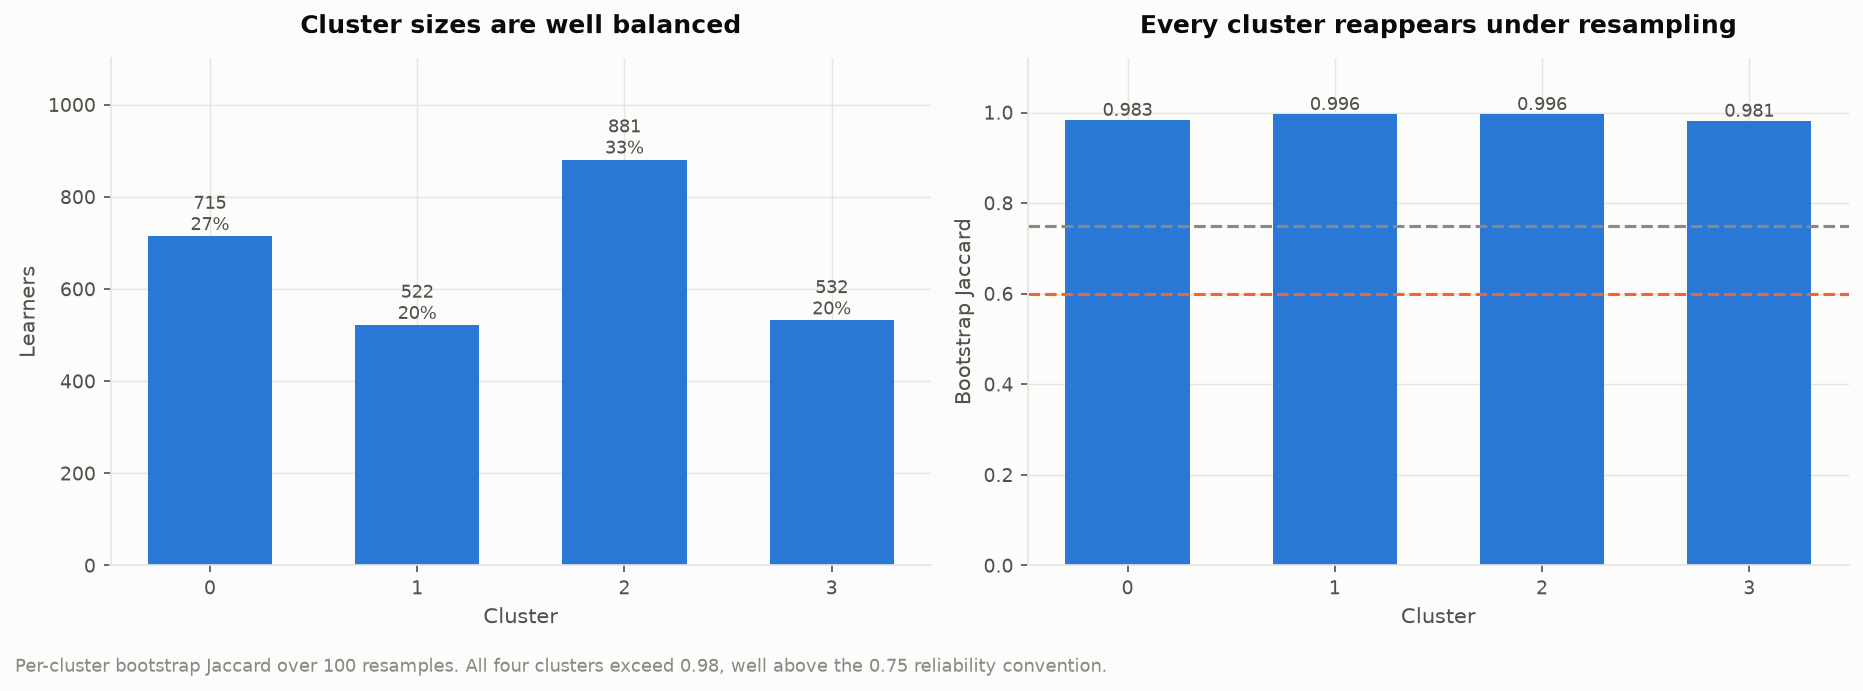

In [9]:
print("stability at the chosen k:")
for key, value in results["EXP-013_stability"].items():
    print(f"  {key}: {value}")

print("\nstability across the whole k range:")
rows = []
for k, s in results["EXP-013_stability_by_k"].items():
    rows.append({
        "k": int(k), "mean_jaccard": s["mean_jaccard"],
        "unstable": s["n_unstable_below_0.60"], "reliable": s["n_reliable_above_0.75"],
        "subsample_ari": s["subsample_ari_mean"],
    })
display(pd.DataFrame(rows).set_index("k"))
display(Image(filename=str(SEG / "03_cluster_sizes_and_stability.png")))

## Experiment 5 — Cluster profiling

Labels were **derived after** looking at the deviations, never assigned first — and
only from features the clustering actually used.

In [10]:
profiles = pd.DataFrame(results["cluster_profiles"]).T
profiles.index = profiles.index.astype(int)
display(profiles[[
    "n_learners", "share", "age_mean", "pct_female", "total_courses_mean",
    "diversity_score_mean", "diversity_ratio_mean", "learning_depth_index_mean",
    "avg_spend_mean", "free_ratio_mean", "avg_course_rating_mean",
    "activity_span_days_mean",
]].sort_index())

print("\nderived labels and the evidence behind them:")
for cluster, info in sorted(results["derived_labels"].items(), key=lambda kv: int(kv[0])):
    print(f"\n  cluster {cluster}: {info['label']}")
    for e in info["evidence"]:
        detail = f"{e['deviation']:+.2f} SD" if e["deviation"] is not None else e["phrase"]
        print(f"      {e['feature']:<22} {detail}")

,n_learners,share,age_mean,pct_female,total_courses_mean,diversity_score_mean,diversity_ratio_mean,learning_depth_index_mean,avg_spend_mean,free_ratio_mean,avg_course_rating_mean,activity_span_days_mean
0,715,0.2698,25.22,49.09,1.3427,1.3399,0.9991,0.09,102.7013,0.6742,3.2617,29.0769
1,522,0.197,24.85,51.15,9.6513,6.841,0.7033,0.9762,93.7721,0.6266,3.1223,226.9751
2,881,0.3325,24.61,50.28,1.5062,1.5017,0.9986,1.7719,77.9612,0.6093,2.8744,40.5131
3,532,0.2008,25.22,53.2,1.2538,1.2519,0.9994,1.003,83.4629,0.7129,3.3924,18.282



derived labels and the evidence behind them:

  cluster 0: Beginner-level Single-course learners
      learning_depth_index   -1.30 SD
      total_courses          -0.46 SD
      preferred_level        100% prefer Beginner

  cluster 1: Category-repeating High-volume learners
      diversity_ratio        -1.84 SD
      total_courses          +1.83 SD

  cluster 2: Advanced-level Non-repeating learners
      learning_depth_index   +1.09 SD
      diversity_ratio        +0.45 SD
      preferred_level        100% prefer Advanced

  cluster 3: Intermediate-level Single-session Single-course learners
      activity_span_days     -0.52 SD
      total_courses          -0.48 SD
      preferred_level        100% prefer Intermediate


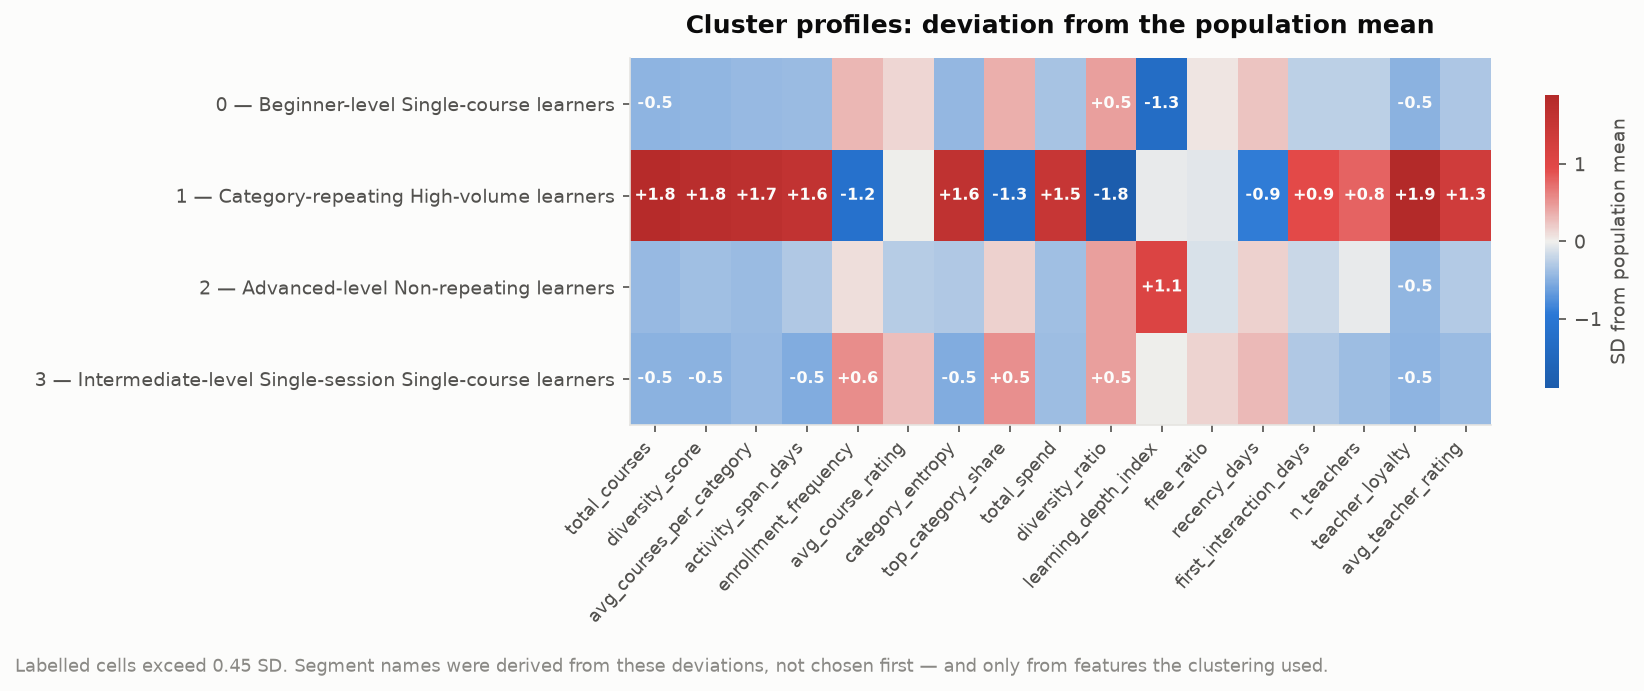

category and level preference by cluster:


,level_mix,top_categories
0,Beginner 100%,"Artificial Intelligence 17%, Programming 15%, ..."
1,"Advanced 44%, Beginner 39%, Intermediate 16%","Artificial Intelligence 17%, Business 12%, Dat..."
2,Advanced 100%,"Design 20%, Business 19%, Machine Learning 9%"
3,Intermediate 100%,"Cybersecurity 19%, Data Science 13%, Artificia..."


In [11]:
display(Image(filename=str(SEG / "04_cluster_profile_heatmap.png")))
print("category and level preference by cluster:")
display(profiles[["level_mix", "top_categories"]].sort_index())

### The headline: the partition is essentially a course-level split

Three of the four clusters are **100% one course level**. For the 54% of learners
with a single enrollment, "preferred level" is simply the level of that one course.

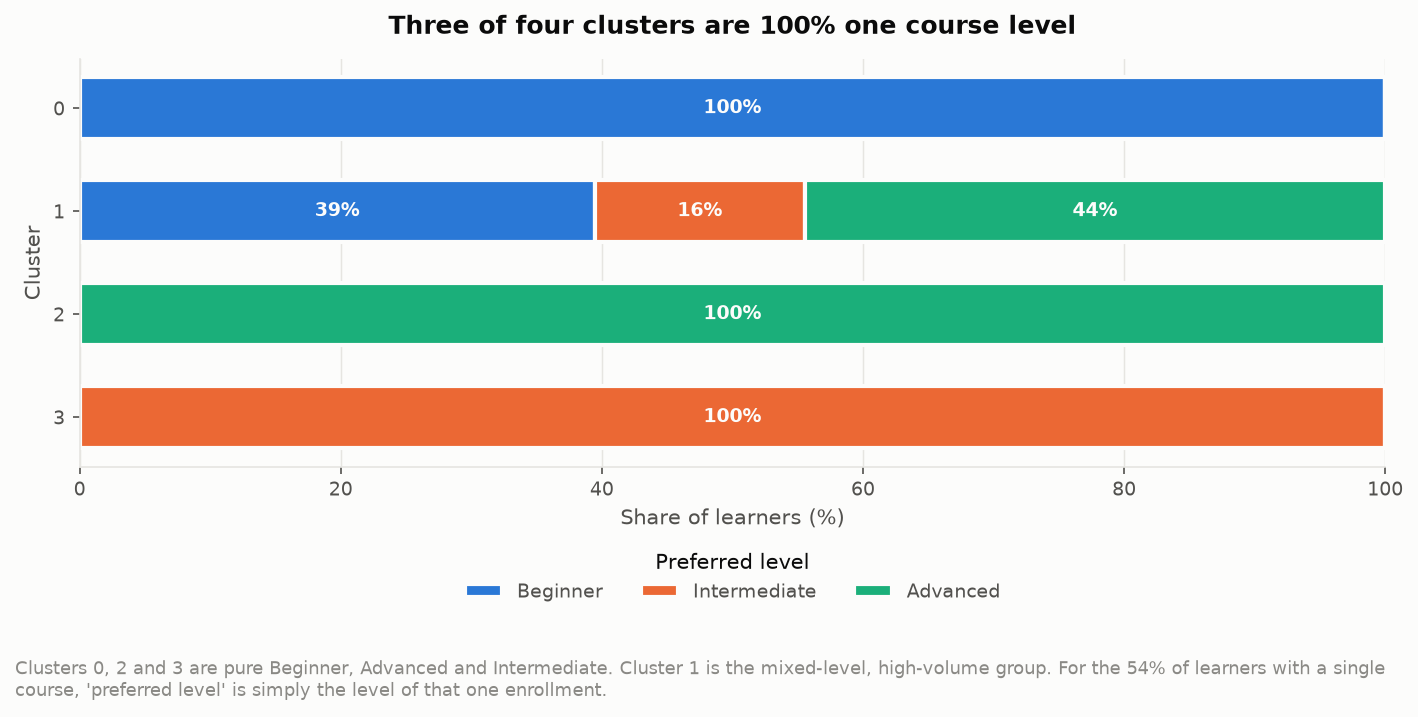

,Advanced,Beginner,Intermediate
0,0.0000,1.0000,0.0000
1,0.4444,0.3946,0.1609
2,1.0000,0.0000,0.0000
3,0.0000,0.0000,1.0000



level ablation — ARI with vs without preferred_level: 0.2533


,representation,n_features,silhouette,mean_bootstrap_jaccard,n_unstable_clusters,top_feature
0,B_proportion,25,0.194600,0.9985,0,preflevel_Intermediate
1,B_no_level,22,0.187723,0.6558,1,cat_share_digital_marketing


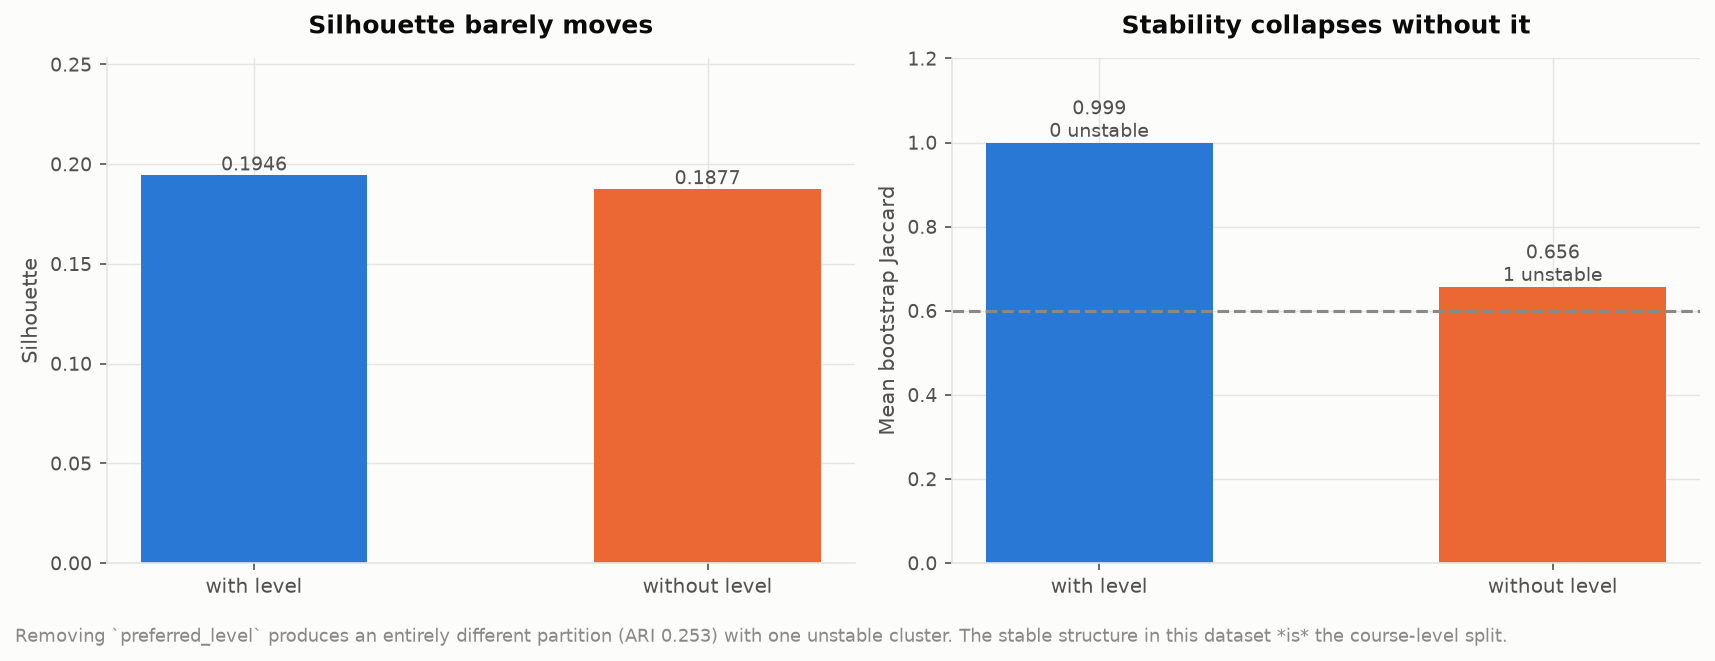

In [12]:
display(Image(filename=str(SEG / "05_level_composition.png")))
display(pd.DataFrame(results["cluster_level_composition"]).T.sort_index())

ablation = results["EXP-011g_level_ablation"]
print(f"\nlevel ablation — ARI with vs without preferred_level: "
      f"{ablation['ari_with_vs_without_level']:.4f}")
display(pd.DataFrame(ablation["arms"])[[
    "representation", "n_features", "silhouette", "mean_bootstrap_jaccard",
    "n_unstable_clusters", "top_feature",
]])
display(Image(filename=str(SEG / "10_level_ablation.png")))

## Experiments 6 and 7 — Demographic sensitivity and the teacher signal

Both are isolated comparisons: one feature block added, everything else held fixed.

EXPERIMENT 6 — behaviour only vs behaviour + demographics


,representation,variant,n_features,silhouette,intra_cluster_similarity,min_cluster_share,seed_stability_ari,mean_bootstrap_jaccard,n_unstable_clusters,demographic_share,top_feature
0,B_proportion,B,25,0.194600,0.416343,0.197,0.999587,0.9985,0,0.0000,preflevel_Intermediate
1,A_proportion,A,27,0.172857,0.414551,0.197,1.000000,0.9909,0,0.0004,preflevel_Intermediate


ARI between the two partitions: 1.0000

EXPERIMENT 7 — core vs core + teacher-derived block


,representation,n_features,silhouette,intra_cluster_similarity,min_cluster_share,mean_bootstrap_jaccard,teacher_block_share,top_feature
0,B_proportion,25,0.194600,0.416343,0.197,0.9985,0.0000,preflevel_Intermediate
1,B_teacher,28,0.195515,0.415378,0.200,0.9891,0.1607,teacher_loyalty


ARI core vs teacher: 0.9904


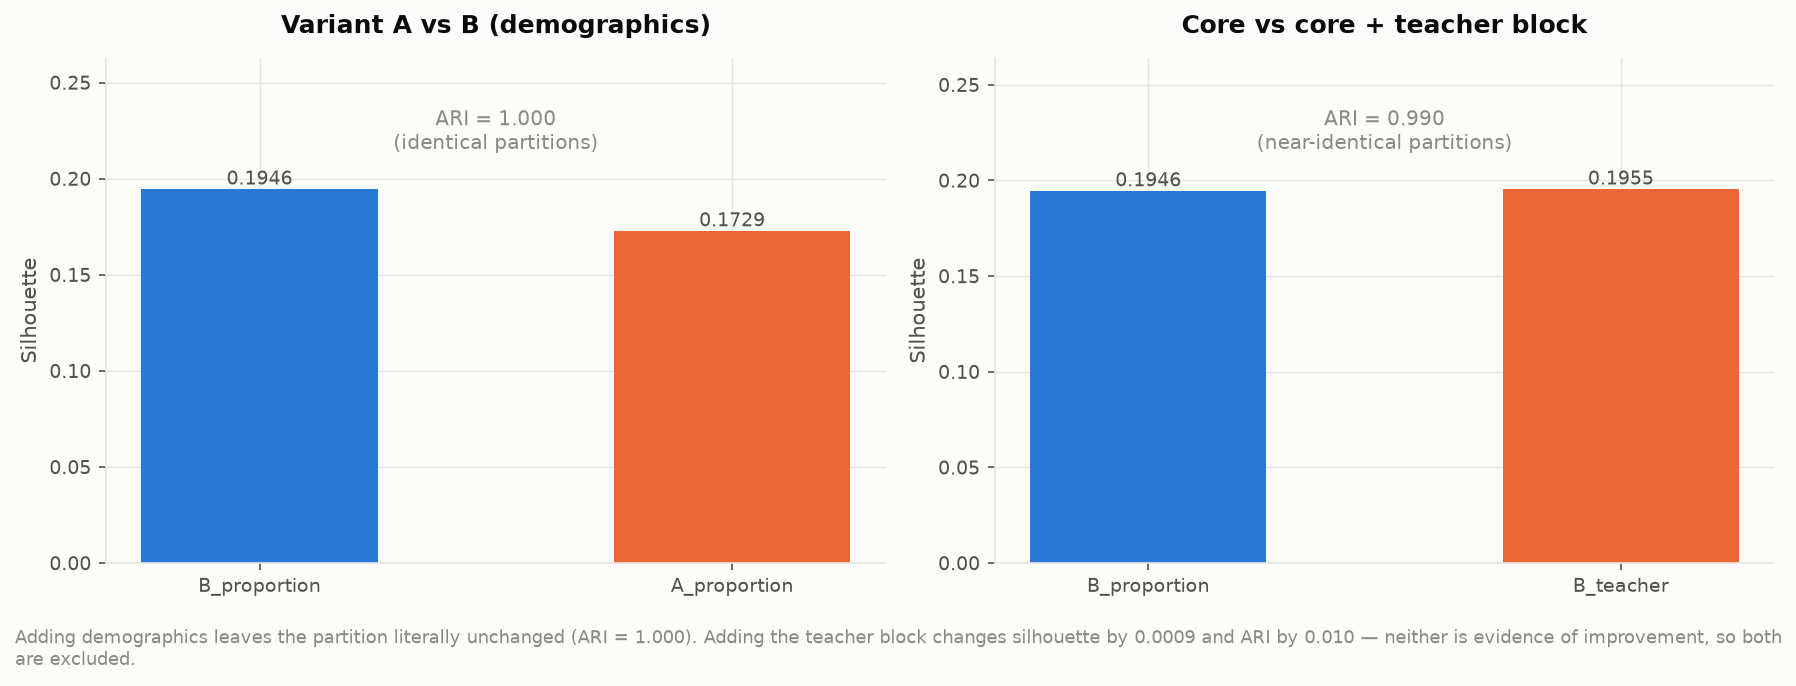

In [13]:
print("EXPERIMENT 6 — behaviour only vs behaviour + demographics")
display(pd.DataFrame(results["EXP-011_variants"]["arms"]))
print(f"ARI between the two partitions: {results['EXP-011_variants']['ari_between_variants']:.4f}")

print("\nEXPERIMENT 7 — core vs core + teacher-derived block")
display(pd.DataFrame(results["EXP-014_teacher"]["arms"]))
print(f"ARI core vs teacher: {results['EXP-014_teacher']['ari_core_vs_teacher']:.4f}")
display(Image(filename=str(SEG / "07_variant_and_teacher.png")))

## Does history length dominate? And does the choice of window matter?

In [14]:
vol = results["EXP-011f_volume_dominance"]
print(f"eta^2(total_courses)                 : {vol['eta_squared_total_courses']:.4f}")
print(f"ARI vs the light/heavy cohort split  : {vol['ari_clusters_vs_light_heavy_cohort']:.4f}")

print("\nfeature dominance by block:")
display(pd.Series(results["EXP-011c_dominance"]["explained_share_per_block"], name="share").to_frame())
print("top features by eta-squared:")
display(pd.Series(results["EXP-011c_dominance"]["top_15_features"], name="eta_squared").head(10).to_frame())

s = results["sensitivity_full_history"]
print(f"\nfull-history sensitivity: best k = {s['best_k']}, "
      f"ARI vs fit-window labels = {s['ari_fit_window_vs_full']:.4f}")

eta^2(total_courses)                 : 0.8198
ARI vs the light/heavy cohort split  : 0.1770

feature dominance by block:


,share
engagement,0.3204
behavioural,0.3186
category,0.0497
level,0.3113


top features by eta-squared:


,eta_squared
preflevel_Intermediate,0.850928
learning_depth_index,0.850573
diversity_ratio,0.830167
total_courses,0.819843
preflevel_Advanced,0.800339
preflevel_Beginner,0.792473
diversity_score,0.760422
avg_courses_per_category,0.703206
activity_span_days,0.634729
enrollment_frequency,0.356954



full-history sensitivity: best k = 8, ARI vs fit-window labels = 0.8465


## Conclusions

1. **Representation:** Variant B (behaviour only), category as a 12-dimensional
   share vector, StandardScaler, no block weighting. The category block never
   dominates under this encoding — the risk Phase 1 flagged did not materialise.
2. **k = 4**, the highest-silhouette value satisfying both pre-registered
   constraints. All four clusters exceed a bootstrap Jaccard of 0.98.
3. **Demographics change nothing** — ARI between Variant A and B is exactly 1.000.
   Variant B wins on parsimony and privacy at zero cost.
4. **Teacher features are rejected**: +0.0009 silhouette, ARI 0.990. Not evidence
   of improvement.
5. **The segmentation is essentially a course-level split.** Removing
   `preferred_level` produces a different partition (ARI 0.253) with an unstable
   cluster, so the stable structure *is* the level split.
6. **Cross-algorithm agreement is weak** — average linkage agrees almost not at all.

Full write-up: `research/segmentation_results.md`,
`research/segmentation_feature_decision.md`, `research/cluster_profiles.md`.